# SEBO Benchmark: Five Black-Box Functions Across Orders of Magnitude

**Author:** Nikolas Karefyllidis, PhD

---

Benchmark of **SEBO** (GP surrogate + ensemble EI/PI/UCB acquisition) against \
**Optuna-TPE**, **TuRBO**, **DE-GP-EI**, and **Random Search** on six synthetic \
black-box functions whose output scales span four orders of magnitude — treating \
each as a completely unknown oracle.

| Function | Dim | Output range | Challenge |
|----------|-----|-------------|-----------|
| F1 · Gaussian 2D | 2 | ≈ [0, 1] | Single smooth peak |
| F2 · Hartmann-3 | 3 | ≈ [0, 3.86] | Smooth, classical benchmark |
| F3 · Scaled ×10⁴ | 4 | ≈ [0, 10 000] | Large scale — log warping active |
| F4 · Multi-Peak 2D | 2 | ≈ [0, 6] | 5 peaks of varying height, overlapping |
| F5 · Hartmann-6 | 6 | ≈ [0, 3.32] | High-dimensional |
| F6 · Asymm. Peaks 4D | 4 | ≈ [0, 8] | 6 peaks, tall=narrow vs short=wide — tests GP exploitation |

**Budget per function:** 5 LHS warm-start + 10 BO iterations = **15 evaluations**.
**Log warping** is active on F3 (large-scale objective); all others use no warping.

## 1. Setup

In [1]:
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skopt.sampler import Lhs

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

from src.optimizers.optimizer import BayesianOptimizer
from src.utils.plot_utilities import setup_matplotlib

setup_matplotlib()

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print("Optuna not available — running without Optuna-TPE.")

try:
    from src.optimizers.wrappers.turbo_solver import suggest as turbo_suggest
    HAS_TURBO = True
except ImportError:
    HAS_TURBO = False
    print("BoTorch not available — running without TuRBO.")

from src.optimizers.wrappers.de_gp_ei_solver import suggest as de_gp_ei_suggest
HAS_DE = True

print(f"Project root : {repo_root}")
print(f"Optuna       : {HAS_OPTUNA}")
print(f"TuRBO        : {HAS_TURBO}")
print(f"DE-GP-EI     : {HAS_DE}")

Project root : /Users/nikolaskarefyllidis/Desktop/02_Portfolio/04_optimization/sample-efficient-optimization
Optuna       : True
TuRBO        : True
DE-GP-EI     : True


## 2. Benchmark Functions

In [2]:
def f1_gaussian_2d(x):
    """Smooth 2D Gaussian. Max = 1.0 at (0.4, 0.6). Range [0, 1]."""
    x = np.asarray(x, dtype=float)
    return float(np.exp(-20.0 * ((x[0] - 0.4)**2 + (x[1] - 0.6)**2)))


def f2_hartmann3(x):
    """Hartmann 3D. Max ≈ 3.86 at (0.114, 0.556, 0.852). Range [0, 3.86]."""
    x = np.asarray(x, dtype=float)
    A = np.array([[3.0, 10.0, 30.0],
                  [0.1, 10.0, 35.0],
                  [3.0, 10.0, 30.0],
                  [0.1, 10.0, 35.0]])
    P = 1e-4 * np.array([[3689, 1170, 2673],
                          [4699, 4387, 7470],
                          [1091, 8732, 5547],
                          [ 381, 5743, 8828]])
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
    return float(sum(alpha[i] * np.exp(-np.sum(A[i] * (x - P[i])**2)) for i in range(4)))


def f3_scaled_4d(x):
    """4D exponential peak x10000. Max = 10000. Range [0, 10000]. Tests log warping."""
    x = np.asarray(x, dtype=float)
    c = np.array([0.35, 0.65, 0.45, 0.55])
    return float(10000.0 * np.exp(-15.0 * float(np.sum((x - c)**2))))


def f4_peaks_2d(x):
    """2D function with 5 overlapping Gaussian peaks of varying heights.
    True maximum computed numerically (peaks overlap, so max > tallest single peak)."""
    x = np.asarray(x, dtype=float)
    centers = [
        (0.2, 0.3, 3.0, 0.025),
        (0.7, 0.5, 5.0, 0.040),
        (0.5, 0.8, 4.0, 0.030),
        (0.3, 0.7, 2.5, 0.020),
        (0.8, 0.2, 3.5, 0.035),
    ]
    return float(sum(
        h * np.exp(-((x[0] - cx)**2 + (x[1] - cy)**2) / (2.0 * var))
        for cx, cy, h, var in centers
    ))


def f5_hartmann6(x):
    """Hartmann 6D. Max approx 3.32 at (0.201, 0.150, 0.477, 0.275, 0.311, 0.657). Range [0, 3.32]."""
    x = np.asarray(x, dtype=float)
    A = np.array([[10.0,  3.0, 17.0,  3.5,  1.7,  8.0],
                  [ 0.05,10.0, 17.0,  0.1,  8.0, 14.0],
                  [ 3.0,  3.5,  1.7, 10.0, 17.0,  8.0],
                  [17.0,  8.0,  0.05,10.0,  0.1, 14.0]])
    P = 1e-4 * np.array([[1312, 1696, 5569,  124, 8283, 5886],
                          [2329, 4135, 8307, 3736, 1004, 9991],
                          [2348, 1451, 3522, 2883, 3047, 6650],
                          [4047, 8828, 8732, 5743, 1091,  381]])
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
    return float(sum(alpha[i] * np.exp(-np.sum(A[i] * (x - P[i])**2)) for i in range(4)))


def f6_peaks_4d(x):
    """4D landscape: 6 Gaussians with varying heights and widths.
    Global max = 8.0 at (0.20,0.40,0.70,0.60) — tall but narrow.
    Shorter peaks are wider and easier to stumble on randomly.
    Tests whether BO preferentially exploits the tallest peak."""
    x = np.asarray(x, dtype=float)
    peaks = [
        ([0.20, 0.40, 0.70, 0.60], 8.0, 0.010),  # global max: tall + narrow
        ([0.75, 0.25, 0.35, 0.80], 5.0, 0.030),  # second tallest: wider
        ([0.50, 0.60, 0.20, 0.45], 4.0, 0.040),
        ([0.85, 0.75, 0.55, 0.15], 3.0, 0.050),
        ([0.30, 0.85, 0.40, 0.30], 2.5, 0.045),
        ([0.65, 0.15, 0.80, 0.70], 2.0, 0.025),
    ]
    return float(sum(
        h * np.exp(-np.sum((x - np.array(ctr))**2) / (2.0 * s2))
        for ctr, h, s2 in peaks
    ))


# Compute true maxima for 2D functions via fine grid scan
_g = np.linspace(0, 1, 500)
_G1, _G2 = np.meshgrid(_g, _g)
_TRUE_MAX_F1 = float(np.vectorize(lambda a, b: f1_gaussian_2d([a, b]))(_G1, _G2).max())
_TRUE_MAX_F4 = float(np.vectorize(lambda a, b: f4_peaks_2d([a, b]))(_G1, _G2).max())

from scipy.optimize import differential_evolution as _de_opt
_TRUE_MAX_F6 = float(
    -_de_opt(lambda x: -f6_peaks_4d(x), [(0.0, 1.0)] * 4,
             seed=42, maxiter=400, popsize=20, tol=1e-9, polish=True).fun
)

FUNCTIONS = {
    "F1 · Gaussian 2D\n[0, 1]":         {"fn": f1_gaussian_2d, "dim": 2, "true_opt": _TRUE_MAX_F1, "warping": None},
    "F2 · Hartmann-3\n[0, 3.86]":       {"fn": f2_hartmann3,   "dim": 3, "true_opt": 3.8628,       "warping": None},
    "F3 · Scaled x10000\n[0, 10 000]":  {"fn": f3_scaled_4d,   "dim": 4, "true_opt": 10000.0,      "warping": "log"},
    "F4 · Multi-Peak 2D\n[0, ~6]":      {"fn": f4_peaks_2d,    "dim": 2, "true_opt": _TRUE_MAX_F4, "warping": None},
    "F5 · Hartmann-6\n[0, 3.32]":       {"fn": f5_hartmann6,   "dim": 6, "true_opt": 3.3224,       "warping": None},
    "F6 · Asymm. Peaks 4D\n[0, ~8]":    {"fn": f6_peaks_4d,    "dim": 4, "true_opt": _TRUE_MAX_F6, "warping": None},
}

for name, cfg in FUNCTIONS.items():
    label = name.split("\n")[0]
    print(f"{label:30s}  dim={cfg['dim']}  true_opt={cfg['true_opt']:.4f}  warping={cfg['warping']}")

F1 · Gaussian 2D                dim=2  true_opt=1.0000  warping=None
F2 · Hartmann-3                 dim=3  true_opt=3.8628  warping=None
F3 · Scaled x10000              dim=4  true_opt=10000.0000  warping=log
F4 · Multi-Peak 2D              dim=2  true_opt=6.3842  warping=None
F5 · Hartmann-6                 dim=6  true_opt=3.3224  warping=None
F6 · Asymm. Peaks 4D            dim=4  true_opt=4.6052  warping=None


## 3. Run Optimizers

In [3]:
N_INIT = 5    # LHS warm-start evaluations
N_ITER = 10   # BO iterations
TOTAL  = N_INIT + N_ITER
SEED   = 42


def _lhs_init(fn, dim, n_init, seed):
    """Run N_INIT LHS evaluations; return (X_obs, y_obs, incumbent_curve)."""
    bounds = [(0.0, 1.0)] * dim
    lhs = Lhs(criterion="maximin", iterations=30)
    X_init = np.array(lhs.generate(bounds, n_init))
    X_obs, y_obs = [], []
    best_y, curve = -np.inf, []
    for x in X_init:
        y = fn(x)
        X_obs.append(x)
        y_obs.append(y)
        best_y = max(best_y, y)
        curve.append(best_y)
    return np.array(X_obs), np.array(y_obs), curve


def run_sebo(fn, dim, warping, n_init=N_INIT, n_iter=N_ITER, seed=SEED):
    """SEBO: GP surrogate + ensemble EI/PI/UCB."""
    bounds = [(0.0, 1.0)] * dim
    opt = BayesianOptimizer(
        bounds=bounds,
        output_warping=warping,
        use_ensemble=True,
        xi=0.01,
        kappa=0.75,
        agree_threshold=0.22,
        candidate_method="sobol",
        seed=seed,
    )
    X_obs, y_obs, curve = _lhs_init(fn, dim, n_init, seed)
    for x, y in zip(X_obs, y_obs):
        opt.observe(x, y)
    for _ in range(n_iter):
        x_next = opt.suggest()
        y_next = fn(x_next)
        opt.observe(x_next, y_next)
        curve.append(opt.best_y)
    return curve, opt.best[0], opt.best[1]


def run_random(fn, dim, n_total=TOTAL, seed=SEED):
    """Pure random search - uniform draws, maximization."""
    rng = np.random.default_rng(seed)
    best_y, curve = -np.inf, []
    for _ in range(n_total):
        y = fn(rng.uniform(0.0, 1.0, dim))
        best_y = max(best_y, y)
        curve.append(best_y)
    return curve


def run_optuna(fn, dim, n_total=TOTAL, seed=SEED):
    """Optuna-TPE. Returns None if Optuna is unavailable."""
    if not HAS_OPTUNA:
        return None
    def objective(trial):
        x = np.array([trial.suggest_float(f"x{i}", 0.0, 1.0) for i in range(dim)])
        return float(fn(x))
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed, n_startup_trials=N_INIT),
    )
    study.optimize(objective, n_trials=n_total, show_progress_bar=False)
    trials = sorted(study.trials, key=lambda t: t.number)
    best_y, curve = -np.inf, []
    for t in trials:
        if t.value is not None:
            best_y = max(best_y, t.value)
        curve.append(best_y)
    return curve


def run_turbo(fn, dim, n_init=N_INIT, n_iter=N_ITER, seed=SEED):
    """TuRBO-1 (BoTorch trust-region BO). Returns None if unavailable."""
    if not HAS_TURBO:
        return None
    bounds = [(0.0, 1.0)] * dim
    X_obs, y_obs, curve = _lhs_init(fn, dim, n_init, seed)
    X_obs, y_obs = list(X_obs), list(y_obs)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i in range(n_iter):
            x_next = turbo_suggest(
                np.array(X_obs), np.array(y_obs), bounds,
                acqf="ts", seed=seed + i,
            )
            y_next = fn(x_next)
            X_obs.append(x_next)
            y_obs.append(y_next)
            curve.append(max(curve[-1], y_next))
    return curve


def run_de_gp_ei(fn, dim, n_init=N_INIT, n_iter=N_ITER, seed=SEED):
    """DE-GP-EI: differential evolution on GP Expected Improvement."""
    bounds = [(0.0, 1.0)] * dim
    X_obs, y_obs, curve = _lhs_init(fn, dim, n_init, seed)
    X_obs, y_obs = list(X_obs), list(y_obs)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i in range(n_iter):
            x_next = de_gp_ei_suggest(
                np.array(X_obs), np.array(y_obs), bounds,
                xi=0.01, seed=seed + i,
            )
            y_next = fn(x_next)
            X_obs.append(x_next)
            y_obs.append(y_next)
            curve.append(max(curve[-1], y_next))
    return curve

In [4]:
results = {}
for name, cfg in FUNCTIONS.items():
    label = name.split("\n")[0]
    print(f"\n> {label} (dim={cfg['dim']}, warping={cfg['warping']})")
    print("  SEBO ...", end=" ", flush=True)
    sebo_curve, sebo_x, sebo_y = run_sebo(cfg["fn"], cfg["dim"], cfg["warping"])
    print(f"{sebo_y:.4g}  |  Random ...", end=" ", flush=True)
    rand_curve = run_random(cfg["fn"], cfg["dim"])
    print(f"{rand_curve[-1]:.4g}  |  Optuna-TPE ...", end=" ", flush=True)
    optuna_curve = run_optuna(cfg["fn"], cfg["dim"])
    if optuna_curve is not None:
        print(f"{optuna_curve[-1]:.4g}", end="")
    print(f"  |  TuRBO ...", end=" ", flush=True)
    turbo_curve = run_turbo(cfg["fn"], cfg["dim"])
    if turbo_curve is not None:
        print(f"{turbo_curve[-1]:.4g}", end="")
    print(f"  |  DE-GP-EI ...", end=" ", flush=True)
    de_curve = run_de_gp_ei(cfg["fn"], cfg["dim"])
    if de_curve is not None:
        print(f"{de_curve[-1]:.4g}")
    results[name] = {
        "sebo":      sebo_curve,
        "random":    rand_curve,
        "optuna":    optuna_curve,
        "turbo":     turbo_curve,
        "de_gp_ei":  de_curve,
        "sebo_best": sebo_y,
        "true_opt":  cfg["true_opt"],
    }

print("\nDone.")


> F1 · Gaussian 2D (dim=2, warping=None)
  SEBO ... 

0.9953  |  Random ... 

0.2604  |  Optuna-TPE ... 

0.8923  |  TuRBO ... 

OMP: pid 18729 tid 259 thread 0 bound to OS proc set {undefined}
OMP: pid 18729 tid 12803 thread 2 bound to OS proc set {undefined}
OMP: pid 18729 tid 14595 thread 1 bound to OS proc set {undefined}
OMP: pid 18729 tid 13059 thread 3 bound to OS proc set {undefined}
OMP: pid 18729 tid 13315 thread 4 bound to OS proc set {undefined}
OMP: pid 18729 tid 13571 thread 5 bound to OS proc set {undefined}


...

5.087  |  Random ... 

2.606  |  Optuna-TPE ... 

2.161  |  TuRBO ... 

3.512  |  DE-GP-EI ... 

1.526

Done.


## 4. Convergence Plots

Saved -> docs/sebo_benchmark_convergence.png


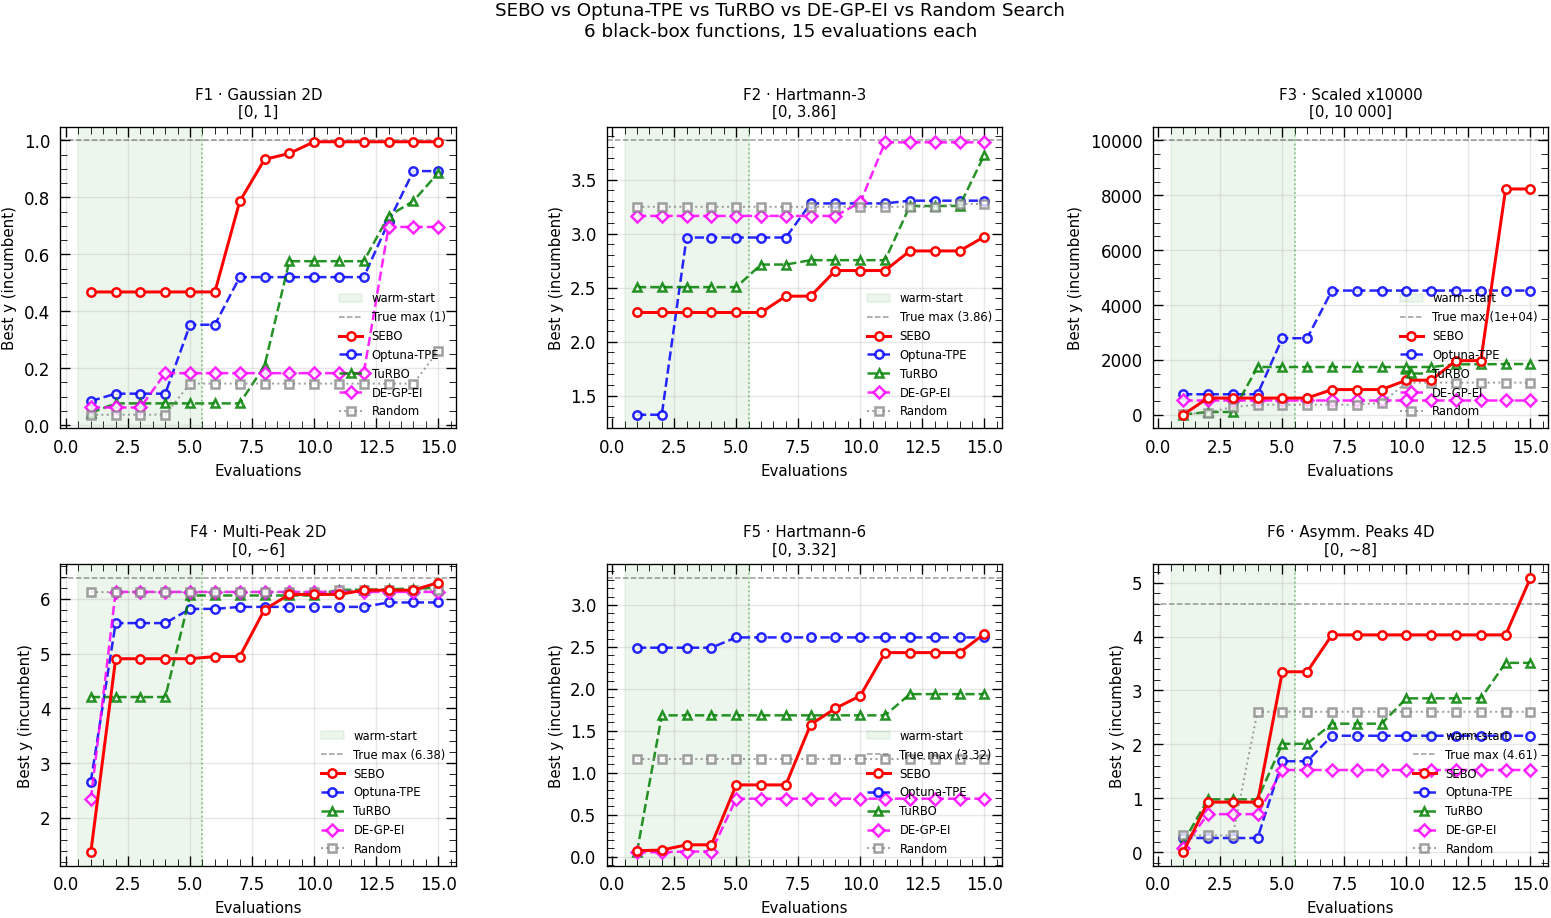

In [5]:
# Marker style consistent with function notebooks (markerfacecolor='w', markeredgewidth=1.5)
_MK = dict(markersize=5, markerfacecolor="w", markeredgewidth=1.5)

# Solver colours match _SOLVER_STYLE used in the NeurIPS BBO function notebooks
SOLVER_STYLE = {
    "SEBO":         {"color": "red",     "marker": "o", "ls": "-",  "lw": 1.8, "alpha": 1.0},
    "Optuna-TPE":   {"color": "blue",    "marker": "o", "ls": "--", "lw": 1.5, "alpha": 0.85},
    "TuRBO":        {"color": "green",   "marker": "^", "ls": "--", "lw": 1.5, "alpha": 0.85},
    "DE-GP-EI":     {"color": "magenta", "marker": "D", "ls": "--", "lw": 1.5, "alpha": 0.85},
    "Random":       {"color": "gray",    "marker": "s", "ls": ":",  "lw": 1.2, "alpha": 0.75},
}

evals = np.arange(1, TOTAL + 1)

# Clean 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
fig.suptitle(
    "SEBO vs Optuna-TPE vs TuRBO vs DE-GP-EI vs Random Search\n"
    "6 black-box functions, 15 evaluations each",
    fontsize=11, y=1.01,
)
fig.subplots_adjust(hspace=0.45, wspace=0.38)

for ax, (name, res) in zip(axes, results.items()):
    ax.axvspan(0.5, N_INIT + 0.5, alpha=0.07, color="green", zorder=0, label="warm-start")
    ax.axvline(N_INIT + 0.5, color="green", linewidth=1.0, linestyle=":", alpha=0.45)
    ax.axhline(
        res["true_opt"], color="black", linewidth=0.9, linestyle="--", alpha=0.40,
        label=f"True max ({res['true_opt']:.3g})",
    )

    for label, curve in [
        ("SEBO",       res["sebo"]),
        ("Optuna-TPE", res["optuna"]),
        ("TuRBO",      res["turbo"]),
        ("DE-GP-EI",   res["de_gp_ei"]),
        ("Random",     res["random"]),
    ]:
        if curve is None:
            continue
        s = SOLVER_STYLE[label]
        ax.plot(
            evals, curve,
            marker=s["marker"],
            linestyle=s["ls"],
            color=s["color"],
            markeredgecolor=s["color"],
            linewidth=s["lw"],
            alpha=s["alpha"],
            label=label,
            zorder=5 if label == "SEBO" else 3,
            **_MK,
        )

    ax.set_xlabel("Evaluations", fontsize=9)
    ax.set_ylabel("Best y (incumbent)", fontsize=9)
    ax.set_title(name, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="lower right", framealpha=0.95)

plt.savefig(
    repo_root / "docs" / "sebo_benchmark_convergence.png",
    dpi=150, bbox_inches="tight",
)
print(f"Saved -> docs/sebo_benchmark_convergence.png")
plt.show()

## 5. Summary

In [6]:
hdr = f"{'Function':<30} {'True max':>10} {'SEBO':>8} {'Optuna':>8} {'TuRBO':>8} {'DE-GP-EI':>9} {'Random':>8} {'SEBO gap':>9}"
print(hdr)
print("-" * len(hdr))

for name, res in results.items():
    label = name.split("\n")[0]
    true  = res["true_opt"]
    sebo  = res["sebo"][-1]
    opt   = res["optuna"][-1]   if res["optuna"]   is not None else float("nan")
    trb   = res["turbo"][-1]    if res["turbo"]    is not None else float("nan")
    de    = res["de_gp_ei"][-1] if res["de_gp_ei"] is not None else float("nan")
    rand  = res["random"][-1]
    gap   = abs(true - sebo) / max(abs(true), 1e-12) * 100
    print(f"{label:<30} {true:>10.4g} {sebo:>8.4g} {opt:>8.4g} {trb:>8.4g} {de:>9.4g} {rand:>8.4g} {gap:>8.1f}%")

print("\nSEBO gap = |true_max - SEBO_best| / |true_max| x 100")

Function                         True max     SEBO   Optuna    TuRBO  DE-GP-EI   Random  SEBO gap
-------------------------------------------------------------------------------------------------
F1 · Gaussian 2D                        1   0.9953   0.8923   0.8861    0.6961   0.2604      0.5%
F2 · Hartmann-3                     3.863    2.971    3.305    3.728     3.845    3.275     23.1%
F3 · Scaled x10000                  1e+04     8232     4528     1849     545.8     1172     17.7%
F4 · Multi-Peak 2D                  6.384    6.299    5.936    6.202     6.129    6.161      1.3%
F5 · Hartmann-6                     3.322    2.655    2.613    1.938    0.6922    1.163     20.1%
F6 · Asymm. Peaks 4D                4.605    5.087    2.161    3.512     1.526    2.606     10.5%

SEBO gap = |true_max - SEBO_best| / |true_max| x 100
